In [405]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot
import scipy.stats as stat
from scipy.stats import chi2
import numpy as ny
from pandas.api.types import CategoricalDtype
# Load the dataset
df = pd.read_csv("titanic_train__1_.csv")
# Gives the view of the glimpse of the dataset
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [407]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [408]:
# Attributes and their distinct values

distinct_val = df.describe(include = 'all').transpose()
distinct_val['distinct_values'] = df.nunique()
distinct_val



,count,unique,top,freq,mean,std,min,25%,50%,75%,max,distinct_values
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0,891
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0,2
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0,3
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,891
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0,88
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0,7
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0,7
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,681
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292,248


It shows that Age has only 714 values and Cabin only has 204 values in a dataset of total values 891

In [410]:
# Attribute range
attribute = df.columns.tolist()
attribute_types = {}


for attr in attribute:
    dtype = df[attr].dtype
    if pd.api.types.is_numeric_dtype(dtype):
        attribute_types[attr]='Numerical'
        minVal = df[attr].min()
        maxVal = df[attr].max()
        attribute_range = f"{maxVal} - {minVal}"
    else:
        attribute_types[attr]= 'Categorical'
    print(f"{attr}:{attribute_types[attr]}")
    if pd.api.types.is_numeric_dtype(dtype):
        print(f" Range:{attribute_range}")
       
    




PassengerId:Numerical
 Range:891 - 1
Survived:Numerical
 Range:1 - 0
Pclass:Numerical
 Range:3 - 1
Name:Categorical
Sex:Categorical
Age:Numerical
 Range:80.0 - 0.42
SibSp:Numerical
 Range:8 - 0
Parch:Numerical
 Range:6 - 0
Ticket:Categorical
Fare:Numerical
 Range:512.3292 - 0.0
Cabin:Categorical
Embarked:Categorical


# Missing Values In the Dataset

 On initial analysis of the dataset, it was noticed that the dataset contains a lot of missing values.
 gives the number of null values in the dataset-- if isnull = 'True' means is a NaN value

In [412]:


df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


# Plot a Heat Map for better view if the missing values in the Dataset

 1) This heatmap shows that Age and Cabin contain enormous missing data or null values. 
 Among Age and Cabin, Cabin contains a maximum number of missing or null values.
 Hence it makes Cabin column impossible to work with, so to clean the data, need to drop Cabin values.
 On initial analysis, Observation is as follows:
 2) PassengerId is just nominal data that just represents the unique Id for each passenger.
 Hence, PassengerId can be dropped from dataset
 3) Name is also just nominal data that gives name of the passenger
 Hence, Name can be dropped from dataset
 4) Ticket is also just nominal data that gives ticket number of the passenger
 Hence,Ticket can be dropped from dataset

<Axes: >

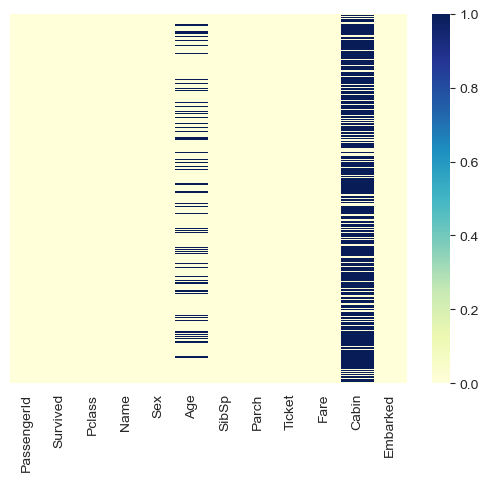

In [415]:
 
sns.heatmap(df.isnull(),yticklabels = False,cmap='YlGnBu')

  This heatmap shows that Age and Cabin contain enormous missing data or null values. 
 Among Age and Cabin, Cabin contains a maximum number of missing or null values.
 Hence it makes Cabin column impossible to work with, so to clean the data, need to drop Cabin values.

In [417]:


df.drop('Cabin', axis = 1,inplace = True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [418]:


df.drop('PassengerId',axis=1,inplace = True)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [419]:


df.drop('Name',axis=1,inplace = True)
df


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [420]:


df.drop('Ticket',axis=1,inplace = True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


<Axes: xlabel='Pclass', ylabel='Age'>

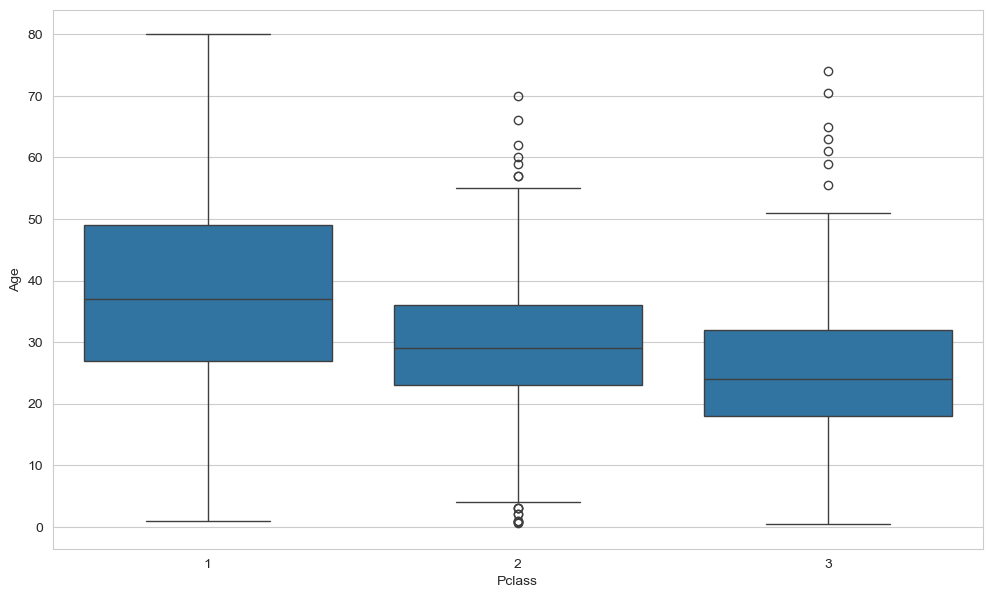

In [421]:
#plotting a boxplot to know where the median value of Age lies when compared as per Passenger Class
plot.figure(figsize=(12,7))
sns.boxplot(x='Pclass',y='Age', data=df)



In [422]:
# As per the observation avg_age of the passengers:
# Pclass-1: Lies between 28 to 48
# Pclass-2: Lies between 25 to 35
# Pclass-3: Lies between 20 to 35
# Hence the missing values in Age should be filled as per observation

df.groupby(by='Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [423]:
# As shown in result the average age:
# Pclass =1 is 38 because generally older people have good economic status to purchase expensive ticket
# Pclass =2 is 29 because generally middle aged people have average economic status.
# Pclass =3 is 25 because generally younger people have poor economic status so they purchase cheap ticket


In [424]:
# now we create a function to substitute null values in Age based on Pclass
def fill_age(data):
    age = data['Age']
    pclass = data['Pclass']
    if pd.isnull(age):
        if(pclass == 1):
            return 38
        elif(pclass ==2):
            return 29
        elif(pclass == 3):
            return 25
    else:
        return age
        
    


In [425]:
df['Age'] = df[['Age','Pclass']].apply(fill_age, axis = 1)

<Axes: >

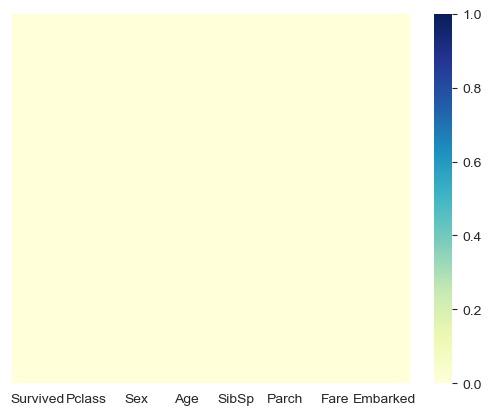

In [426]:
sns.heatmap(df.isnull(),yticklabels = False,cmap='YlGnBu')

In [427]:
# As shown in heatmap all the null values of Age and Cabin are resolved.
# Only single value in Embark was left that has NaN so we dropped that as well
df.dropna(inplace = True)

<Axes: >

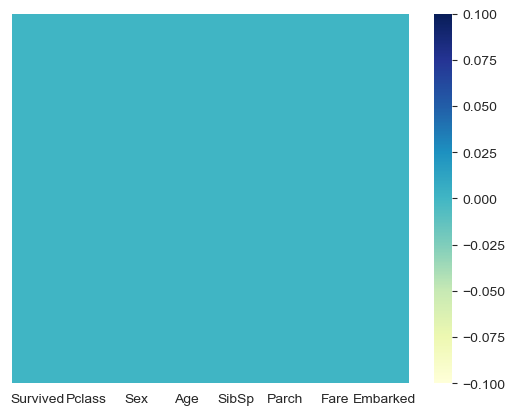

In [428]:
sns.heatmap(df.isnull(),yticklabels = False,cmap='YlGnBu')

# UNIVARIATE Analysis

Record of Survival of people Survived
0    549
1    340
Name: count, dtype: int64


62 % People dies out of 891 died with titanic


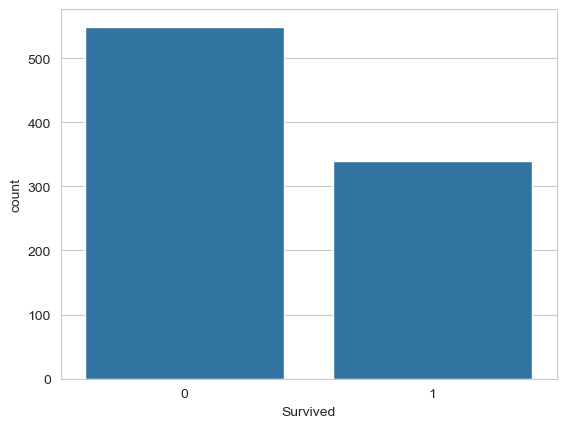

In [431]:

#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=df)

death = df['Survived'].value_counts()
print("Record of Survival of people",death)
print('\n')
death_per = round((df['Survived'].value_counts().values[0]/891)* 100)
print(death_per, "% People dies out of 891 died with titanic")
# In the count plot we can clearly see that more than 500 people out of 891 survived and
# around 350 people could not survive.

No of people in each Pclass: Pclass
3    491
1    214
2    184
Name: count, dtype: int64


percentage of people in each class  Pclass
3    55.106622
1    24.017957
2    20.650954
Name: count, dtype: float64


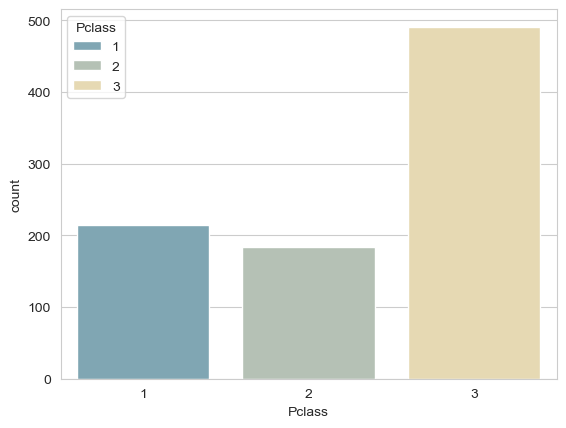

In [432]:
sns.set_style('whitegrid')
sns.countplot(data=df, x= 'Pclass', hue='Pclass',palette = 'blend:#7AB,#EDA')

people_data = df['Pclass'].value_counts()
print("No of people in each Pclass:",people_data)
print('\n')
per_people = (df['Pclass'].value_counts()/891)*100
print("percentage of people in each class ",per_people)

# In this countplot we can observe that Pclass = 3 is most crowded

No of people in each Gender: Sex
male      577
female    312
Name: count, dtype: int64


percentage of people in each gender  Pclass
3    55.106622
1    24.017957
2    20.650954
Name: count, dtype: float64


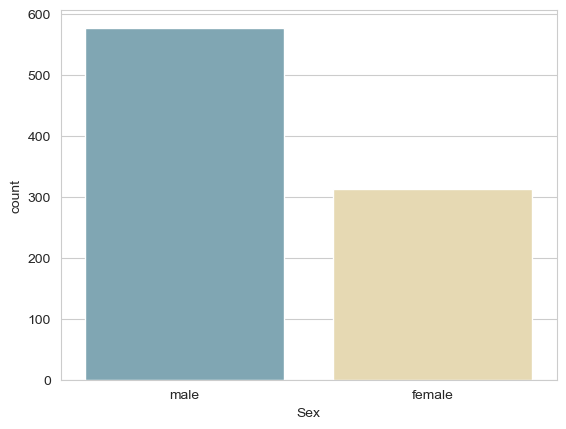

In [433]:
sns.set_style('whitegrid')
sns.countplot(data=df, x= 'Sex', hue = 'Sex',palette = 'blend:#7AB,#EDA')

gender_data = df['Sex'].value_counts()
print("No of people in each Gender:",gender_data)
print('\n')

per_gender = (df['Sex'].value_counts()/891)*100

print("percentage of people in each gender ",per_people)

# In this countplot we can observe that male travelling more in titanic than females


Count of people travelling with Siblings: SibSp
0    606
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


percentage of people travelling with siblings  SibSp
0    68.013468
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: count, dtype: float64


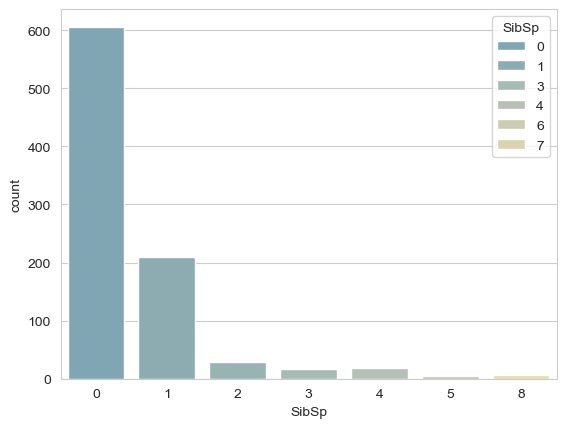

In [434]:
sns.set_style('whitegrid')
sns.countplot(data=df, x= 'SibSp', hue = 'SibSp',palette = 'blend:#7AB,#EDA')

count_sib = df['SibSp'].value_counts()
print("Count of people travelling with Siblings:",count_sib)
print('\n')

per_sib = (count_sib/891)*100
print("percentage of people travelling with siblings ",per_sib)
# It shows that majority of the people are travelling alone, almost 68% of people.
# Only 23% of people are travelling with 1 sibling

Count of people travelling with children: Parch
0    676
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


percentage of people travelling with children  Parch
0    75.869809
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


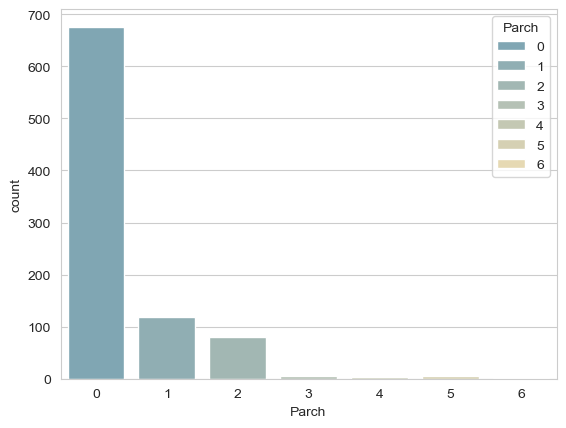

In [435]:
sns.set_style('whitegrid')
sns.countplot(data=df, x= 'Parch', hue = 'Parch',palette = 'blend:#7AB,#EDA')

count_parent = df['Parch'].value_counts()
print("Count of people travelling with children:",count_parent)
print('\n')

per_parent = (count_parent/891)*100
print("percentage of people travelling with children ",per_parent)
# It shows that majority of the people are travelling without children, almost 75% of people.
# Only 13% of people are travelling with 1 child

Count of people travelling from different city: Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


percentage of people travelling from different city  Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64


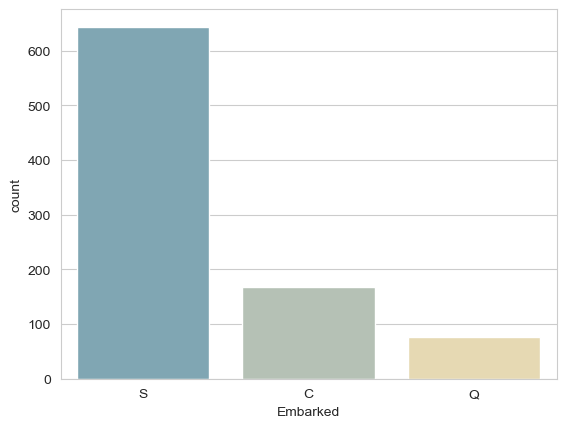

In [436]:
sns.set_style('whitegrid')
sns.countplot(data=df, x= 'Embarked', hue = 'Embarked',palette = 'blend:#7AB,#EDA')

city = df['Embarked'].value_counts()
print("Count of people travelling from different city:",city)
print('\n')

per_people_city = (city/891)*100
print("percentage of people travelling from different city ",per_people_city)

# It shows that majority of the people are travelling from city 'S' approx 72%.


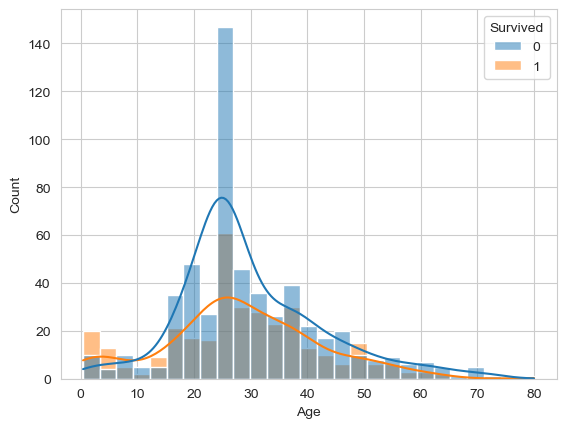

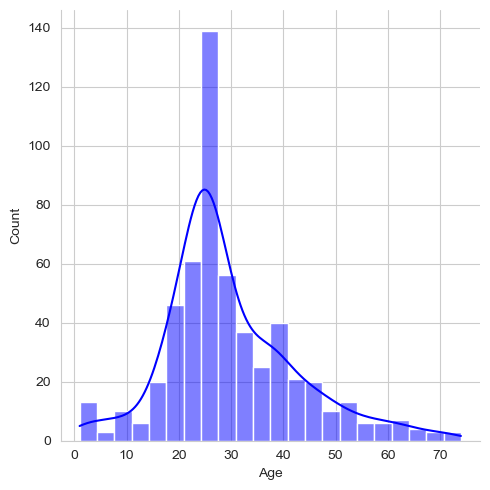

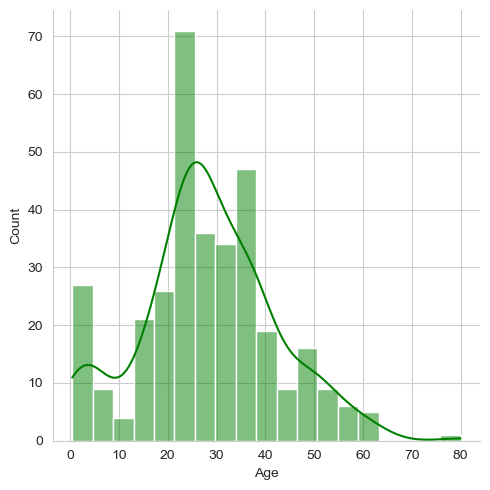

In [437]:
#Histogram
sns.histplot(data=df,  x = 'Age', hue ='Survived',color = 'blue',kde= True,multiple="layer",element = 'bars')

# DisPlot
sns.set_style('whitegrid')
sns.displot(df[df['Survived']==0]['Age'],kde = True,kind = 'hist', color ='blue')
sns.displot(df[df['Survived']==1]['Age'], kde = True, kind = 'hist', color = 'green')


#In this graph we can clearly observe a normal distribution of Age
# Most people that could not survive lies between age of 15 to 45, 
# and suprisingly that survived also lies between 15 to 45
# small no of people who survived also lies between age of 0 to 10, signifying they are infant and children

# Bivariate Analysis

<Axes: xlabel='Survived', ylabel='count'>

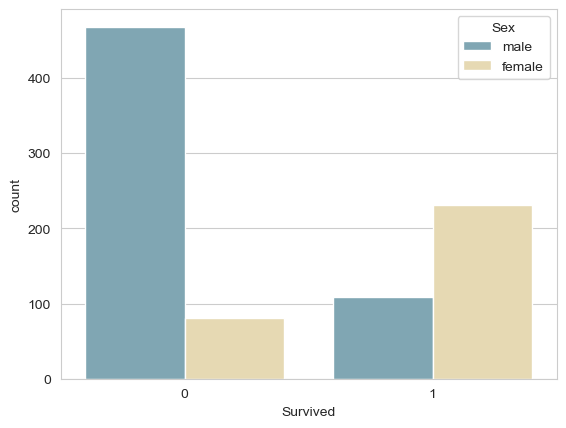

In [439]:
#Countplot

sns.set_style('whitegrid')
sns.countplot(data = df,x='Survived', hue = 'Sex', palette = 'blend:#7AB,#EDA')

# In this count plot we can visualize that no of males who survived is very less as compared to female.

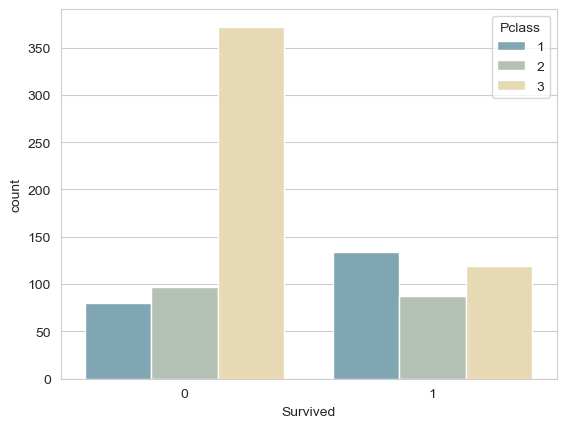

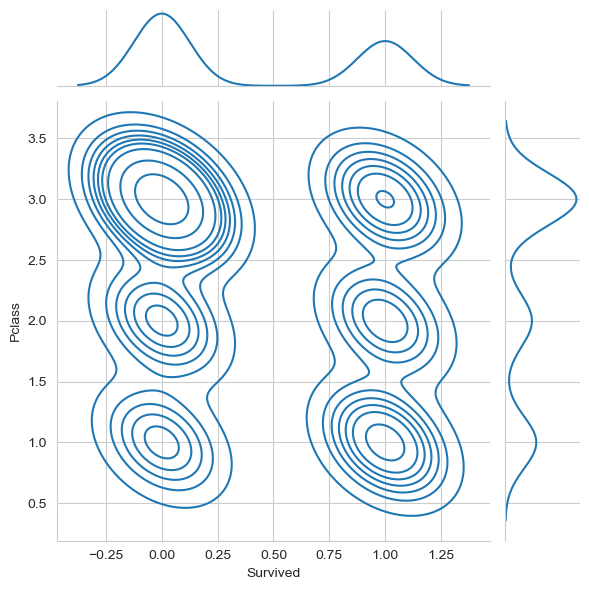

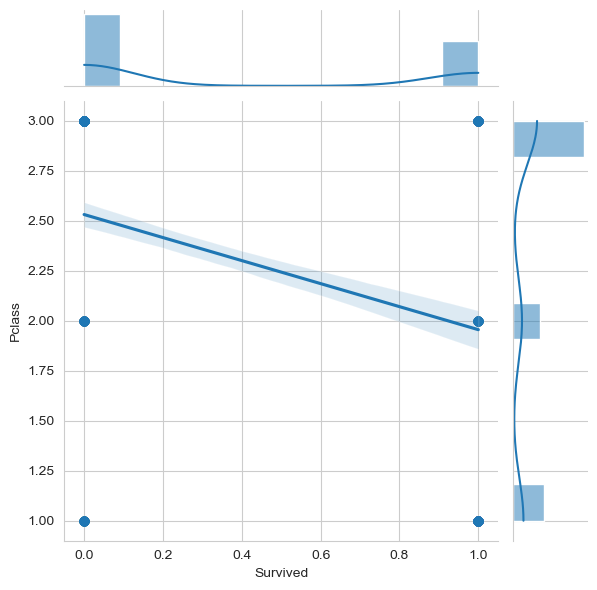

In [440]:
# CountPlot
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass',data = df,palette = 'blend:#7AB,#EDA')

#JointPlot -- used for plotting Bivariate and Univariate Gra
sns.jointplot(data =df,x='Survived',y = 'Pclass',kind = 'kde')
sns.jointplot(data =df,x='Survived',y = 'Pclass',kind = 'reg')

# In this countplot we can see that most of the people that could not survive belonged to Pclass = 3,
# and comparatively no of people who did not survive is low in Pclass = 1
# Also, highest number of people survived in Pclass =1, and suprisingly people in Pclass = 3 survived more than people in Pclass = 2

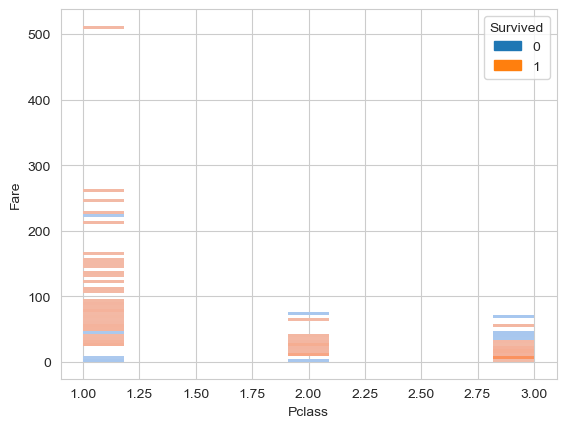

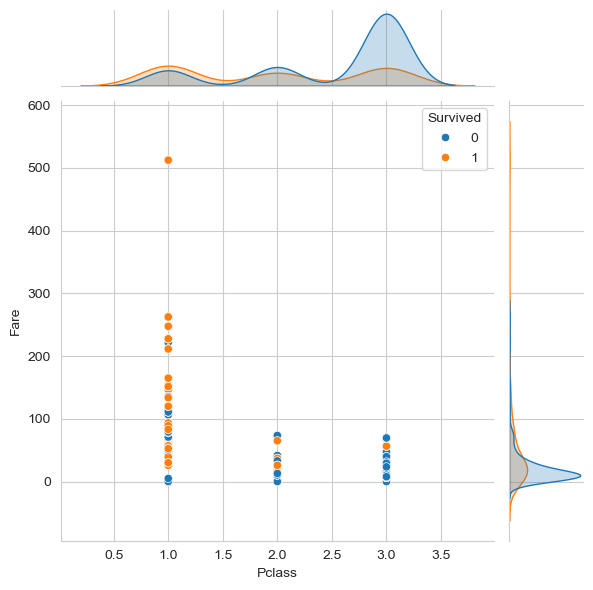

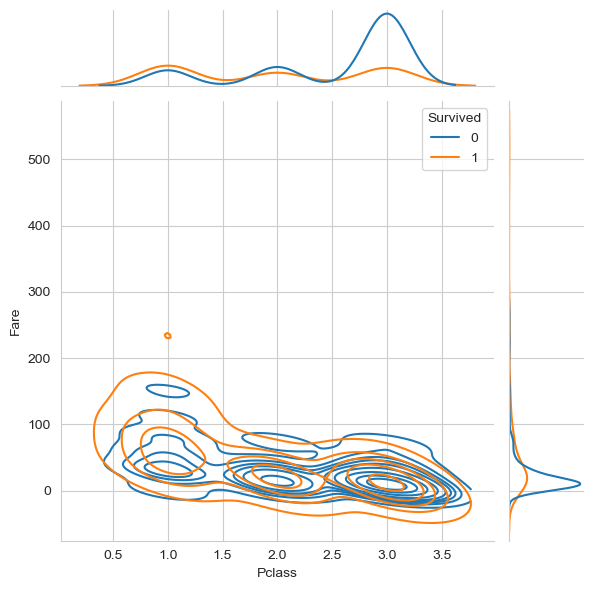

In [441]:
# Histogram

sns.histplot(data=df,x='Pclass',y='Fare',hue='Survived',kde=True)

#JointPlot
sns.jointplot(data=df,x='Pclass',y= 'Fare',hue='Survived',kind='scatter')
sns.jointplot(data=df,x='Pclass',y= 'Fare',hue='Survived',kind='kde')


# In this we can clearly observe that fare is highest in Pclass = 3 and fairly largest number of people survived in Pclass =3
# There is less difference between fare of Pclass 2 and Pclass =1
# huge number of people in Pclass = 3 did not survive.

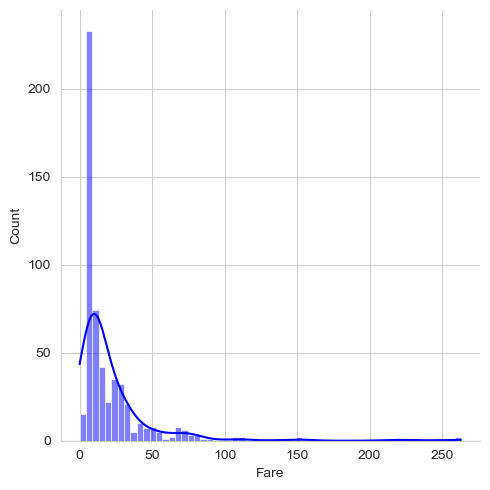

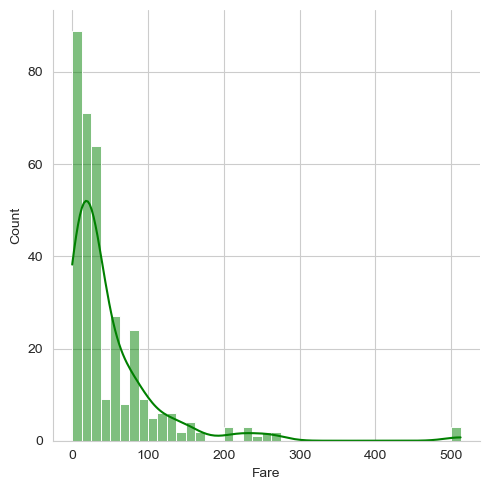

In [442]:
#DistPlot

sns.displot(df[df['Survived']==0]['Fare'],kde = True, kind = 'hist', color = 'blue')
sns.displot(df[df['Survived']==1]['Fare'],kde = True, kind = 'hist',color = 'green')

# These plotting show skewness whic signifies that:
# Huge Number of people paying highest amount for Pclass = 3 (rich people) survived.

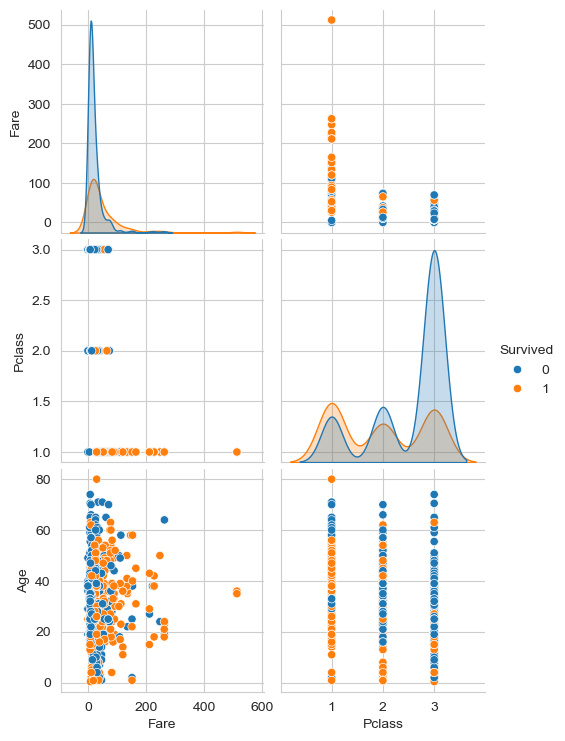

In [443]:
#PairPlot

sns.pairplot(df,x_vars=['Fare','Pclass'],y_vars=['Fare','Pclass','Age'], hue = 'Survived')

In [444]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [445]:
def familytype(size):
    if size == 0:
        return  'Alone'
    elif size >= 1 and size <= 4:
        return  'Medium'
    else:
        return 'Large'

In [446]:
df['Family_size'] = df['SibSp'] + df['Parch']
df['Family_type'] = df['Family_size'].apply(familytype)
df.to_csv('modified_titanic_dataset.csv', index=False)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_size,Family_type
0,0,3,male,22.0,1,0,7.2500,S,1,Medium
1,1,1,female,38.0,1,0,71.2833,C,1,Medium
2,1,3,female,26.0,0,0,7.9250,S,0,Alone
3,1,1,female,35.0,1,0,53.1000,S,1,Medium
4,0,3,male,35.0,0,0,8.0500,S,0,Alone
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0,Alone
887,1,1,female,19.0,0,0,30.0000,S,0,Alone
888,0,3,female,25.0,1,2,23.4500,S,3,Medium
889,1,1,male,26.0,0,0,30.0000,C,0,Alone


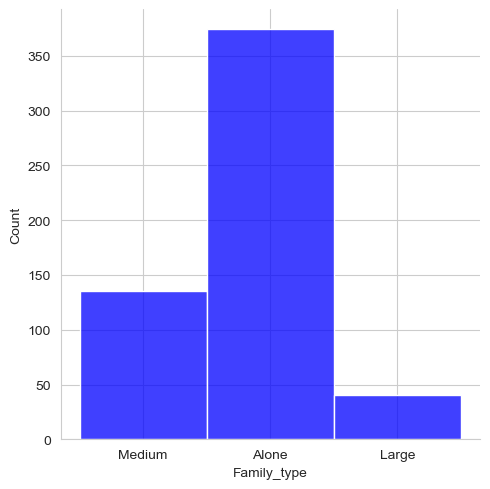

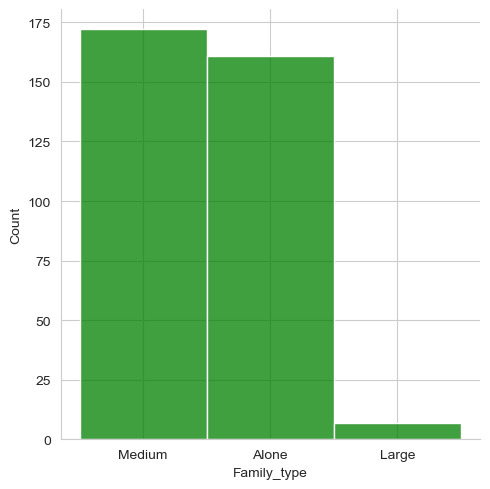

In [447]:
#DistPlot

sns.displot(df[df['Survived']==0]['Family_type'], kind = 'hist', color = 'blue')
sns.displot(df[df['Survived']==1]['Family_type'], kind = 'hist',color = 'green')

# This shows that people with large families have very less probability to survive

# Correlation

In [449]:
# Converting Categorical values into dummy/indicator variables for better correlation statistics

#Sex,Embarked,Family_type is a Categorical value in the dataset so, we convert it first into dummy indicators.

sex = pd.get_dummies(df['Sex'],drop_first = True,dtype = int)
embarked = pd.get_dummies(df['Embarked'],drop_first = True,dtype = int)
family_type = pd.get_dummies(df['Family_type'],drop_first = True,dtype = int)
df.drop(['Sex','Embarked','Family_type','SibSp','Parch'],axis =1,inplace = True)
df = pd.concat([df,sex,embarked,family_type],axis = 1)
df


,Survived,Pclass,Age,Fare,Family_size,male,Q,S,Large,Medium
0,0,3,22.0,7.2500,1,1,0,1,0,1
1,1,1,38.0,71.2833,1,0,0,0,0,1
2,1,3,26.0,7.9250,0,0,0,1,0,0
3,1,1,35.0,53.1000,1,0,0,1,0,1
4,0,3,35.0,8.0500,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,1,0,1,0,0
887,1,1,19.0,30.0000,0,0,0,1,0,0
888,0,3,25.0,23.4500,3,0,0,1,0,1
889,1,1,26.0,30.0000,0,1,0,0,0,0


In [450]:
correlation = df.corr()
print("Relationship between different attributes is shown in this table",correlation)

Relationship between different attributes is shown in this table              Survived    Pclass       Age      Fare  Family_size      male  \
Survived     1.000000 -0.335549 -0.054899  0.255290     0.018277 -0.541585   
Pclass      -0.335549  1.000000 -0.400979 -0.548193     0.064221  0.127741   
Age         -0.054899 -0.400979  1.000000  0.118665    -0.252539  0.085232   
Fare         0.255290 -0.548193  0.118665  1.000000     0.218658 -0.179958   
Family_size  0.018277  0.064221 -0.252539  0.218658     1.000000 -0.203191   
male        -0.541585  0.127741  0.085232 -0.179958    -0.203191  1.000000   
Q            0.004536  0.220558 -0.070862 -0.116684    -0.059007 -0.075217   
S           -0.151777  0.076466  0.006319 -0.163758     0.078197  0.121405   
Large       -0.113523  0.140733 -0.197207  0.124888     0.783054 -0.047450   
Medium       0.265727 -0.208880 -0.079590  0.223403     0.342539 -0.293725   

                    Q         S     Large    Medium  
Survived     0.004536 

<Axes: >

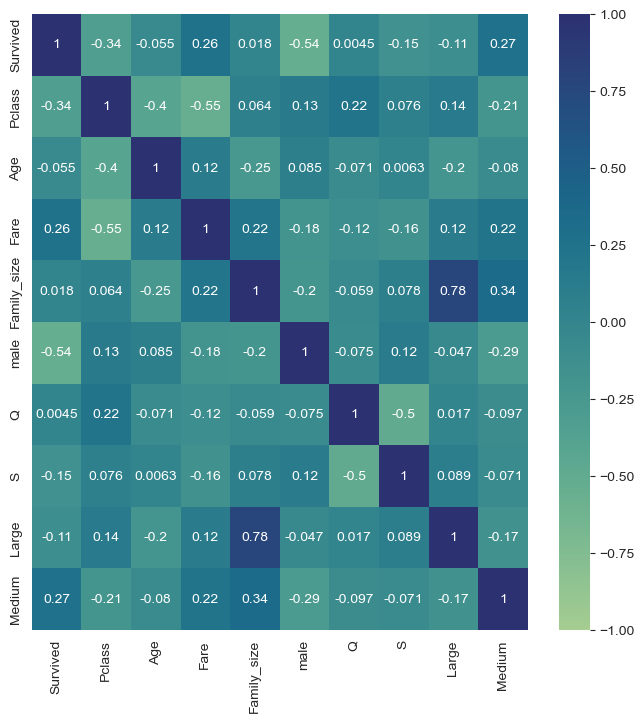

In [451]:
plot.figure(figsize = (8,8))
sns.heatmap(correlation,annot = True,cmap = 'crest',vmin = -1, vmax =1)

In [452]:
# Correlation Coffecient , with this we can select highly correlated features

def correlation(data, threshhold):
    col_cor = set()
    correlation = df.corr()
    for i in range(len(correlation.columns)):
        for j in range(i):
            if abs (correlation.iloc[i,j])>threshhold:
                col = correlation.columns[i]
                col_cor.add(col)
    return col_cor
            
    
    

In [453]:
correlated_features = correlation(df,0.7)
print("Attributes that are 70% correlated are:",correlated_features)
correlated_features = correlation(df,0.5)
print("Attributes that are 50% correlated are:",correlated_features)
correlated_features = correlation(df,0.4)
print("Attributes that are 40% correlated are:",correlated_features)


Attributes that are 70% correlated are: {'Large'}
Attributes that are 50% correlated are: {'male', 'Fare', 'Large'}
Attributes that are 40% correlated are: {'Age', 'Large', 'Fare', 'S', 'male'}


# Conclusions:

# 1)  Travelling in Pclass = 1 is the cheapest to travel and highly risky as most of the people did not survive the disaster.
# 2)  Travelling in Pclass = 3 is the most expensive class and most suitable has the majority of the people survived.
# 3)  Most of the males did not survive the disaster.
# 4)  People travelling in large families most likely did not survive the disaster.
# 5) Chi Square Test between Survived vs Pclass, Survived vs Sex, Survived vs fare, Survived vs Family_type shows the relationship.
# 6) There is high correlation of attribute 'Survived' with Sex, Family_type, Fare

In [456]:
df

,Survived,Pclass,Age,Fare,Family_size,male,Q,S,Large,Medium
0,0,3,22.0,7.2500,1,1,0,1,0,1
1,1,1,38.0,71.2833,1,0,0,0,0,1
2,1,3,26.0,7.9250,0,0,0,1,0,0
3,1,1,35.0,53.1000,1,0,0,1,0,1
4,0,3,35.0,8.0500,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,1,0,1,0,0
887,1,1,19.0,30.0000,0,0,0,1,0,0
888,0,3,25.0,23.4500,3,0,0,1,0,1
889,1,1,26.0,30.0000,0,1,0,0,0,0


In [457]:
df


,Survived,Pclass,Age,Fare,Family_size,male,Q,S,Large,Medium
0,0,3,22.0,7.2500,1,1,0,1,0,1
1,1,1,38.0,71.2833,1,0,0,0,0,1
2,1,3,26.0,7.9250,0,0,0,1,0,0
3,1,1,35.0,53.1000,1,0,0,1,0,1
4,0,3,35.0,8.0500,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,1,0,1,0,0
887,1,1,19.0,30.0000,0,0,0,1,0,0
888,0,3,25.0,23.4500,3,0,0,1,0,1
889,1,1,26.0,30.0000,0,1,0,0,0,0


In [458]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.80


Training Errors [0.01406469760900142, 0.10267229254571031, 0.1209563994374121, 0.12517580872011247, 0.12658227848101267, 0.14486638537271446, 0.14345991561181437, 0.15049226441631502, 0.14627285513361465, 0.1575246132208158, 0.15893108298171588, 0.16315049226441636, 0.16174402250351616, 0.16455696202531644, 0.16455696202531644]
Testing Errors [0.2528089887640449, 0.1910112359550562, 0.2247191011235955, 0.2191011235955056, 0.2359550561797753, 0.2247191011235955, 0.2528089887640449, 0.2134831460674157, 0.2415730337078652, 0.1966292134831461, 0.2191011235955056, 0.2078651685393258, 0.2247191011235955, 0.1797752808988764, 0.202247191011236]


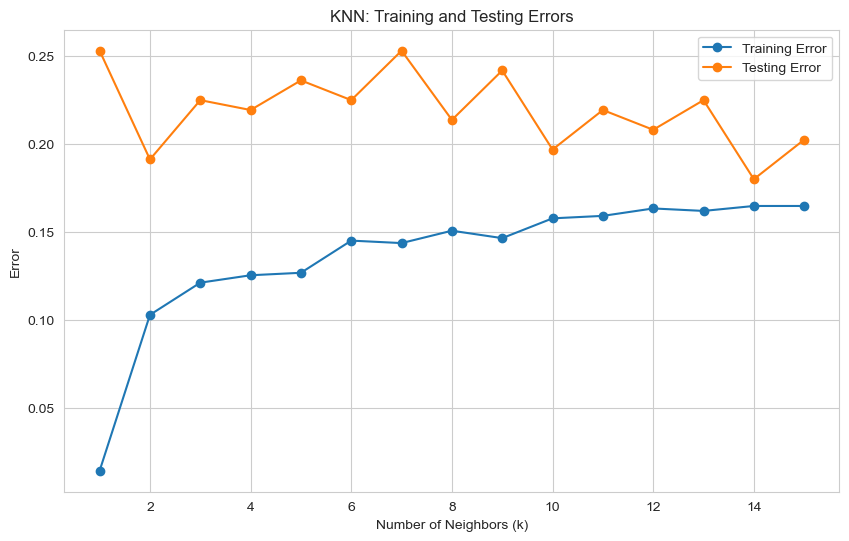

In [459]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training and testing errors for different values of k
train_errors = []
test_errors = []

# Test k values from 1 to 15
k_values = range(1, 16)

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    
    y_train_pred = knn_model.predict(X_train)
    y_test_pred = knn_model.predict(X_test)
    
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

print("Training Errors",train_errors)
print("Testing Errors",test_errors)

# Plot the errors
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, marker='o', label='Training Error')
plt.plot(k_values, test_errors, marker='o', label='Testing Error')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error')
plt.title('KNN: Training and Testing Errors')
plt.legend()
plt.grid(True)
plt.show()


Precision: 0.73
Recall: 0.75
F1-Score: 0.74
Cross-Validation Scores: [0.63483146 0.68539326 0.75842697 0.73033708 0.7740113 ]
Mean Cross-Validation Score: 0.72


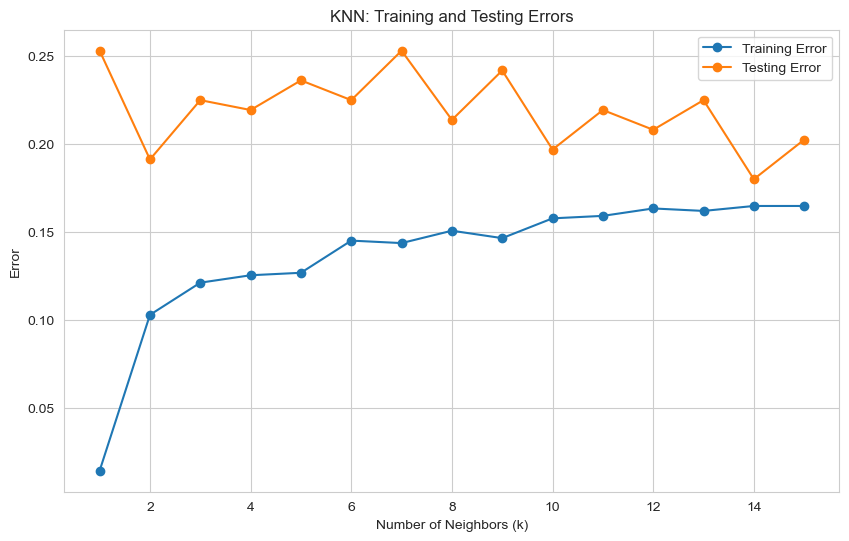

In [460]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Define features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training and testing errors for different values of k
train_errors = []
test_errors = []

# Test k values from 1 to 15
k_values = range(1, 16)

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    
    y_train_pred = knn_model.predict(X_train)
    y_test_pred = knn_model.predict(X_test)
    
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

# Perform cross-validation
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=15), X, y, cv=5)
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Mean Cross-Validation Score: {cv_scores.mean():.2f}')

# Plot the errors
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, marker='o', label='Training Error')
plt.plot(k_values, test_errors, marker='o', label='Testing Error')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error')
plt.title('KNN: Training and Testing Errors')
plt.legend()
plt.grid(True)
plt.show()








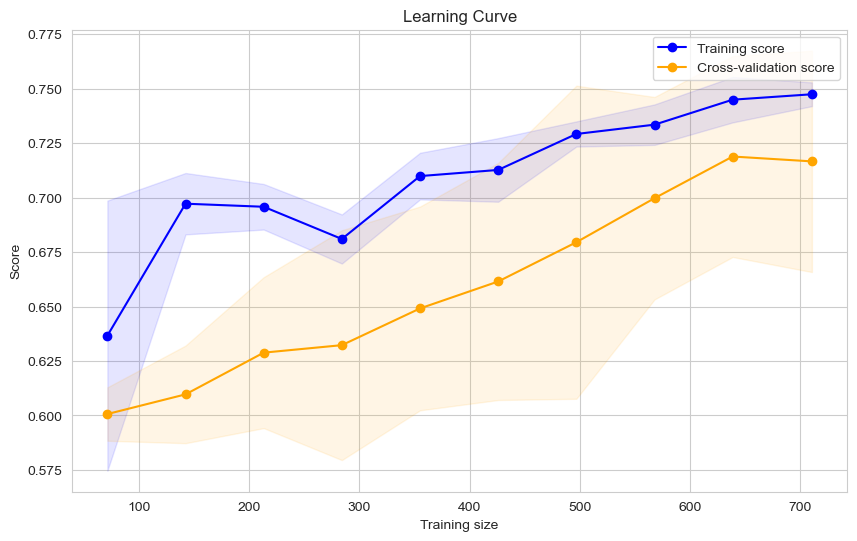

In [461]:
from sklearn.model_selection import learning_curve
import numpy as np

# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(knn_model, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.xlabel('Training size')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()
